In [1]:
from utilities import init_bigquery_client
from google.cloud import bigquery
import os
import pandas as pd
import numpy as np
import plotly.express as px

from plotnine import *

from datetime import date, datetime

#init BigQuery client
bq = init_bigquery_client()

Using BigQuery credentials: etl-testing-478716-c0b6c2c512e0.json


### Bulk Queries

In [2]:
def perform_bulk_queries(start_date, end_date): 
    # Read from the 'events' table in the posthog_etl dataset
    #Pre filtered data only includes ios events
    
    #check to see if start_date and end_date are date type 
    if isinstance(start_date, date) and isinstance(end_date, date):
        query = f"""
            SELECT * FROM `etl-testing-478716.posthog_etl.events` 
            WHERE TIMESTAMP_TRUNC(timestamp, DAY) BETWEEN TIMESTAMP("{start_date}") AND TIMESTAMP("{end_date}") 
            ORDER BY timestamp ASC
        """
        posthog_events_df = bq.query(query).to_dataframe()
    else:
        raise TypeError("start_date and end_date must be date types") 
    # Read from the 'events' table in BigQuery
    query = """
        SELECT *
        FROM `etl-testing-478716.firebase_etl_prod.events`
    """
    events_df = bq.query(query).to_dataframe()

    # Read from the 'userinvites' table in BigQuery
    query = """
        SELECT *
        FROM `etl-testing-478716.firebase_etl_prod.userinvites`
    """
    userinvites_df = bq.query(query).to_dataframe()

    # Read from the 'users' table in BigQuery
    query = """
        SELECT *
        FROM `etl-testing-478716.firebase_etl_prod.users`
    """
    users_df = bq.query(query).to_dataframe()

    return posthog_events_df, events_df, userinvites_df, users_df

## User Specific Date Grid Creation

In [3]:
#function to create user specific date grid
def create_user_specific_date_grid(master_df, end_date):
    """
    Create a user-date grid where each user has rows from their creation date 
    (or first activity if createdAt is missing) to the end date.
    
    Parameters:
    - master_df: DataFrame with user_id, date, and createdAt columns
    - end_date: The end date for all users (string or datetime)
    
    Returns:
    - DataFrame with user_id and date columns
    """
    end_date = pd.to_datetime(end_date).date()
    
    # Get each user's start date (createdAt or first activity)
    user_start_dates = master_df.groupby('user_id').agg({
        'createdAt': 'first',  # Get createdAt (should be same for all rows of a user)
        'date': 'min'  # Get first activity date as fallback
    }).reset_index()
    
    # Normalize createdAt to timezone-naive and convert to date
    user_start_dates['createdAt_date'] = pd.to_datetime(
        user_start_dates['createdAt']
    ).dt.tz_localize(None).dt.date
    
    # Ensure date column is also date type
    user_start_dates['date'] = pd.to_datetime(user_start_dates['date']).dt.date
    
    # Use createdAt if available, otherwise use first activity date
    user_start_dates['start_date'] = user_start_dates['createdAt_date'].fillna(
        user_start_dates['date']
    )
    
    # Create date range for each user
    all_user_dates = []
    for _, row in user_start_dates.iterrows():
        user_id = row['user_id']
        start = row['start_date']
        
        # Generate date range for this user
        dates = pd.date_range(start=start, end=end_date, freq='D').date
        user_dates = pd.DataFrame({
            'user_id': user_id,
            'date': dates
        })
        all_user_dates.append(user_dates)
    
    # Concatenate all user date ranges
    return pd.concat(all_user_dates, ignore_index=True)

## User Daily Activity Table creation

Gives you an aggregated summary of users event actions per day over their lifespan

In [4]:
def create_user_daily_activity_table(posthog_events_df, events_df, userinvites_df, users_df, end_date):
    #Creating user daily interactions dataframe
    grouped_posthog_events_df = posthog_events_df.groupby(['distinct_id',
                                        pd.Grouper(key='timestamp', freq='D')]).size().reset_index(name='event_count')
    grouped_posthog_events_df = grouped_posthog_events_df.rename(columns={'timestamp': 'date'})
    user_info_cols = ['fullName', 'phoneNumber', 'username', 'email']

    # Merge on phoneNumber
    merged_by_phone = pd.merge(
        grouped_posthog_events_df,
        users_df,
        left_on='distinct_id',
        right_on='phoneNumber',
        how='left',
        suffixes=('', '_user')
    )
    #removing test phone number 
    merged_by_phone = merged_by_phone[merged_by_phone['phoneNumber'] != '+11111111111']

    #dropping duplicates based on distinct_id, date, and phoneNumber
    # Sort so rows with email and username come first
    merged_by_phone = merged_by_phone.sort_values(
        by=['email', 'username'],
        ascending=[False, False]
    )

    # Drop duplicates, keeping the first (which will have email/username if available)
    merged_by_phone = merged_by_phone.drop_duplicates(subset=['distinct_id', 'date', 'phoneNumber'], keep='first')

    #dropping rows where all user info columns are NaN
    filtered_by_phone = merged_by_phone.dropna(subset=user_info_cols, how='all')

    # Merge on user_id
    merged_by_id = pd.merge(
        grouped_posthog_events_df,
        users_df,
        left_on='distinct_id',
        right_on='user_id',
        how='left',
        suffixes=('', '_user')
    )

    filtered_by_id = merged_by_id.dropna(subset=user_info_cols, how='all')

    # Concatenate the two filtered DataFrames, removing duplicates if any
    final_merged = pd.concat([filtered_by_phone, filtered_by_id]).drop_duplicates(subset=grouped_posthog_events_df.columns.tolist())

    # Find unmatched rows (those not in either filtered merge)
    matched_indices = pd.concat([filtered_by_phone, filtered_by_id]).index
    unmatched = grouped_posthog_events_df.loc[~grouped_posthog_events_df.index.isin(matched_indices)]

    #Creating user daily events created dataframe
    grouped_events_df = events_df.groupby(['user_id',
                                        pd.Grouper(key='createdAt', freq='D')]).size().reset_index(name='events_created_count')
    grouped_events_df = grouped_events_df.rename(columns={'createdAt': 'date'})

    #merging on phone number to userid
    grouped_events_df = pd.merge(grouped_events_df, users_df[['phoneNumber', 'user_id']], left_on='user_id', right_on='user_id', how='left')
    # Merge on user_id info
    grouped_events_df = pd.merge(
        grouped_events_df,
        users_df,
        left_on='user_id',
        right_on='user_id',
        how='left',
        suffixes=('', '_user')
    )

    #dropping rows where all user info columns are NaN
    grouped_events_df = grouped_events_df.dropna(subset=user_info_cols, how='all')
    
    #Creating user daily events joined dataframe
    grouped_userinvites_df = userinvites_df.groupby(['user_id',
                                        pd.Grouper(key='createdAt', freq='D'),'status']).size().reset_index(name='events_joined_count')
    grouped_userinvites_df = grouped_userinvites_df.rename(columns={'createdAt': 'date'})
    grouped_userinvites_df = pd.pivot_table(grouped_userinvites_df, index=['user_id', 'date'],
                                            columns='status', values='events_joined_count', fill_value=0).reset_index()

    #merging on user information
    grouped_userinvites_df = pd.merge(
        grouped_userinvites_df,
        users_df,
        left_on='user_id',
        right_on='user_id',
        how='left',
        suffixes=('', '_user')
    )

    #dropping rows where all user info columns are NaN
    grouped_userinvites_df = grouped_userinvites_df.dropna(subset=user_info_cols, how='all')
    # Select only relevant columns from each table
    final_merged_reduced = final_merged[['user_id', 'date', 'event_count']]
    grouped_events_reduced = grouped_events_df[['user_id', 'date', 'events_created_count']]
    grouped_userinvites_reduced = grouped_userinvites_df[['user_id', 'date', 'accepted', 'invited', 'rejected']]

    # Merge all on user_id and date
    from functools import reduce
    dfs = [final_merged_reduced, grouped_events_reduced, grouped_userinvites_reduced]
    master_df = reduce(
        lambda left, right: pd.merge(left, right, on=['user_id', 'date'], how='outer'),
        dfs
    )

    # Fill NaN activity counts with 0
    activity_cols = ['event_count', 'events_created_count', 'accepted', 'invited', 'rejected']
    master_df[activity_cols] = master_df[activity_cols].fillna(0)
    master_df['date'] = pd.to_datetime(master_df['date']).dt.date

    #merge createdAt to master_df
    master_df = pd.merge(master_df, users_df[['user_id', 'createdAt']], on='user_id', how='left')

    # Create user-specific date grid
    user_date_grid = create_user_specific_date_grid(master_df, end_date)

    # Merge the grid with the master table
    master_df = pd.merge(user_date_grid, master_df, on=['user_id', 'date'], how='left')

    # Fill NaN activity counts with 0
    activity_cols = ['event_count', 'events_created_count', 'accepted', 'invited', 'rejected']
    master_df[activity_cols] = master_df[activity_cols].fillna(0)
    # Add user info back (deduplicate users_df first)
    user_info_cols = ['user_id', 'fullName', 'phoneNumber', 'username', 'email']
    users_info = users_df[user_info_cols].drop_duplicates('user_id')
    master_df = pd.merge(master_df, users_info, on='user_id', how='left')

    return master_df

## Running Functions

In [5]:
start_date = date(2026, 1, 1)
end_date = date(2026, 2, 13)

posthog_events_df, events_df, userinvites_df, users_df = perform_bulk_queries(start_date, end_date)

#filtering events_df, userinvites_df, and users_df to match timeframe of start and end
events_df = events_df[(events_df['createdAt'] >= pd.to_datetime(start_date).tz_localize('UTC')) & (events_df['createdAt'] <= pd.to_datetime(end_date).tz_localize('UTC'))]
userinvites_df = userinvites_df[(userinvites_df['createdAt'] >= pd.to_datetime(start_date).tz_localize('UTC')) & (userinvites_df['createdAt'] <= pd.to_datetime(end_date).tz_localize('UTC'))]
# users_df = users_df[(users_df['createdAt'] >= pd.to_datetime(start_date).tz_localize('UTC')) & (users_df['createdAt'] <= pd.to_datetime(end_date).tz_localize('UTC'))]

#creating master_df with user daily activity
master_df = create_user_daily_activity_table(posthog_events_df, events_df, userinvites_df, users_df, end_date)

print(f"Length of master_df: {len(master_df)}")

/opt/miniconda3/envs/heyyall/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.


Length of master_df: 4506


## Creating User Churn Table

Current state snapshot for each user based on app activity and business activity (creating events and joining events)

In [6]:
import pandas as pd
from datetime import date


def create_user_churn_state_table(master_df, inactivity_threshold_days=14, end_date=None):
    """
    Create a user churn state table from the daily activity table.
    Calculates separate churn states for app activity and business activity.
    
    Parameters:
    - master_df: User daily activity DataFrame with user_id, date, and activity columns
    - inactivity_threshold_days: Number of days of inactivity before considering churned
    - end_date: The reference date for calculating current state (usually today)
    
    Returns:
    - DataFrame with current churn state per user
    """
    if end_date is None:
        end_date = pd.to_datetime('today').date()
    else:
        end_date = pd.to_datetime(end_date).date()
    
    # Define activity columns
    app_activity_cols = ['event_count']
    biz_activity_cols = ['events_created_count', 'accepted', 'invited', 'rejected']
    
    # Create flags for different types of activity
    master_df['has_app_activity'] = master_df[app_activity_cols].sum(axis=1) > 0
    master_df['has_biz_activity'] = master_df[biz_activity_cols].sum(axis=1) > 0
    
    # Group by user to calculate state metrics
    user_states = []
    
    # Define activity types to loop through
    activity_types = {
        'app': 'has_app_activity',
        'biz': 'has_biz_activity'
    }
    
    for user_id, user_data in master_df.groupby('user_id'):
        # Skip users with no activity at all
        if not user_data['has_app_activity'].any() and not user_data['has_biz_activity'].any():
            continue
        
        user_state = {'user_id': user_id}
        
        # Loop through each activity type
        for activity_name, activity_flag in activity_types.items():
            active_days = user_data[user_data[activity_flag]].copy()
            
            if len(active_days) > 0:
                first_active_date = active_days['date'].min()
                last_active_date = active_days['date'].max()
                days_since_last_activity = (end_date - last_active_date).days
                
                # Determine churn state
                if days_since_last_activity <= inactivity_threshold_days:
                    churn_state = 'active'
                    churn_date = None
                else:
                    churn_state = 'churned'
                    churn_date = last_active_date + pd.Timedelta(days=inactivity_threshold_days)
                
                # Count churn cycles
                active_sorted = active_days.sort_values('date')
                active_sorted['days_since_prev'] = active_sorted['date'].diff().apply(lambda x: x.days if pd.notna(x) else None)
                times_churned = (active_sorted['days_since_prev'] > inactivity_threshold_days).sum()
                
                # Check for reactivation
                if times_churned > 0 and churn_state == 'active':
                    churn_state = 'reactivated'
                
                # Store metrics for this activity type
                user_state[f'{activity_name}_churn_state'] = churn_state
                user_state[f'{activity_name}_churn_date'] = churn_date
                user_state[f'{activity_name}_times_churned'] = times_churned
                user_state[f'days_since_last_{activity_name}_activity'] = days_since_last_activity
                user_state[f'first_{activity_name}_active_date'] = first_active_date
                user_state[f'last_{activity_name}_active_date'] = last_active_date
            else:
                # No activity for this type
                user_state[f'{activity_name}_churn_state'] = 'never_active'
                user_state[f'{activity_name}_churn_date'] = None
                user_state[f'{activity_name}_times_churned'] = 0
                user_state[f'days_since_last_{activity_name}_activity'] = None
                user_state[f'first_{activity_name}_active_date'] = None
                user_state[f'last_{activity_name}_active_date'] = None
        
        # Determine user segment based on primary activity
        total_events_created = user_data['events_created_count'].sum()
        total_events_attended = user_data['accepted'].sum()
        total_app_interactions = user_data['event_count'].sum()

        #adding totals to the user state for later use in segmentation and analysis
        user_state['total_events_created'] = total_events_created
        user_state['total_events_attended'] = total_events_attended
        user_state['total_app_interactions'] = total_app_interactions
        
        user_states.append(user_state)
    
    return pd.DataFrame(user_states)

In [7]:
churn_df = create_user_churn_state_table(master_df, inactivity_threshold_days=14, end_date='2026-02-13')

In [9]:
#showing never active based on app is web user or user who was active prior to Jan 1st
never_active = churn_df[(churn_df['app_churn_state'] == 'never_active')]
never_active = never_active.merge(users_df[['user_id', 'username']], on='user_id', how='left')

print(f"Users who were never active in the app: {len(never_active)}")
print(f"Users who do not have ios accounts: {never_active[never_active['username'].isna()].shape[0]}")
print(f"Users who most likely used app prior to start_date: {never_active[never_active['username'].notna()].shape[0]}")

Users who were never active in the app: 130
Users who do not have ios accounts: 117
Users who most likely used app prior to start_date: 13


In [15]:
#Churn Rate Metrics
# Overall churn rates
filtered_churn_df = churn_df[~(churn_df['app_churn_state'] == 'never_active')]
app_churn_rate = (filtered_churn_df['app_churn_state'] == 'churned').sum() / len(filtered_churn_df) * 100
biz_churn_rate = (filtered_churn_df['biz_churn_state'] == 'churned').sum() / len(filtered_churn_df) * 100

# Reactivation rate
app_reactivation_rate = (filtered_churn_df['app_churn_state'] == 'reactivated').sum() / len(filtered_churn_df) * 100
biz_reactivation_rate = (filtered_churn_df['biz_churn_state'] == 'reactivated').sum() / len(filtered_churn_df) * 100

print(f"App Activity Churn Rate: {app_churn_rate:.2f}%")
print(f"App Activity Usage Resurrection Rate: {app_reactivation_rate:.2f}%")

print(f"Event/Joiner Churn Rate: {biz_churn_rate:.2f}%")
print(f"Event/Joiner Resurrection Rate: {biz_reactivation_rate:.2f}%")

App Activity Churn Rate: 33.02%
App Activity Usage Resurrection Rate: 8.49%
Event/Joiner Churn Rate: 17.92%
Event/Joiner Resurrection Rate: 5.66%


In [17]:
# Churn time metrics
# Average days since last activity (for churned users)
churn_df['app_churn_date'] = pd.to_datetime(churn_df['app_churn_date'])
churn_df['biz_churn_date'] = pd.to_datetime(churn_df['biz_churn_date'])
churn_df['first_app_active_date'] = pd.to_datetime(churn_df['first_app_active_date'])
churn_df['first_biz_active_date'] = pd.to_datetime(churn_df['first_biz_active_date'])

avg_days_inactive_app = churn_df[churn_df['app_churn_state'] == 'churned']['days_since_last_app_activity'].mean()
avg_days_inactive_biz = churn_df[churn_df['biz_churn_state'] == 'churned']['days_since_last_biz_activity'].mean()

# Time to churn (first activity to churn date)
churn_df['app_days_to_churn'] = (churn_df['app_churn_date'] - churn_df['first_app_active_date']).dt.days
churn_df['biz_days_to_churn'] = (churn_df['biz_churn_date'] - churn_df['first_biz_active_date']).dt.days

print(f"Average days since last app activity for churned users: {avg_days_inactive_app:.2f} days")
print(f"Average days since last business activity for churned users: {avg_days_inactive_biz:.2f} days")
print(f"Average days to churn from first app activity: {churn_df[churn_df['app_churn_state'] == 'churned']['app_days_to_churn'].mean():.2f} days")
print(f"Average days to churn from first business activity: {churn_df[churn_df['biz_churn_state'] == 'churned']['biz_days_to_churn'].mean():.2f} days")

Average days since last app activity for churned users: 27.40 days
Average days since last business activity for churned users: 26.52 days
Average days to churn from first app activity: 17.66 days
Average days to churn from first business activity: 14.82 days


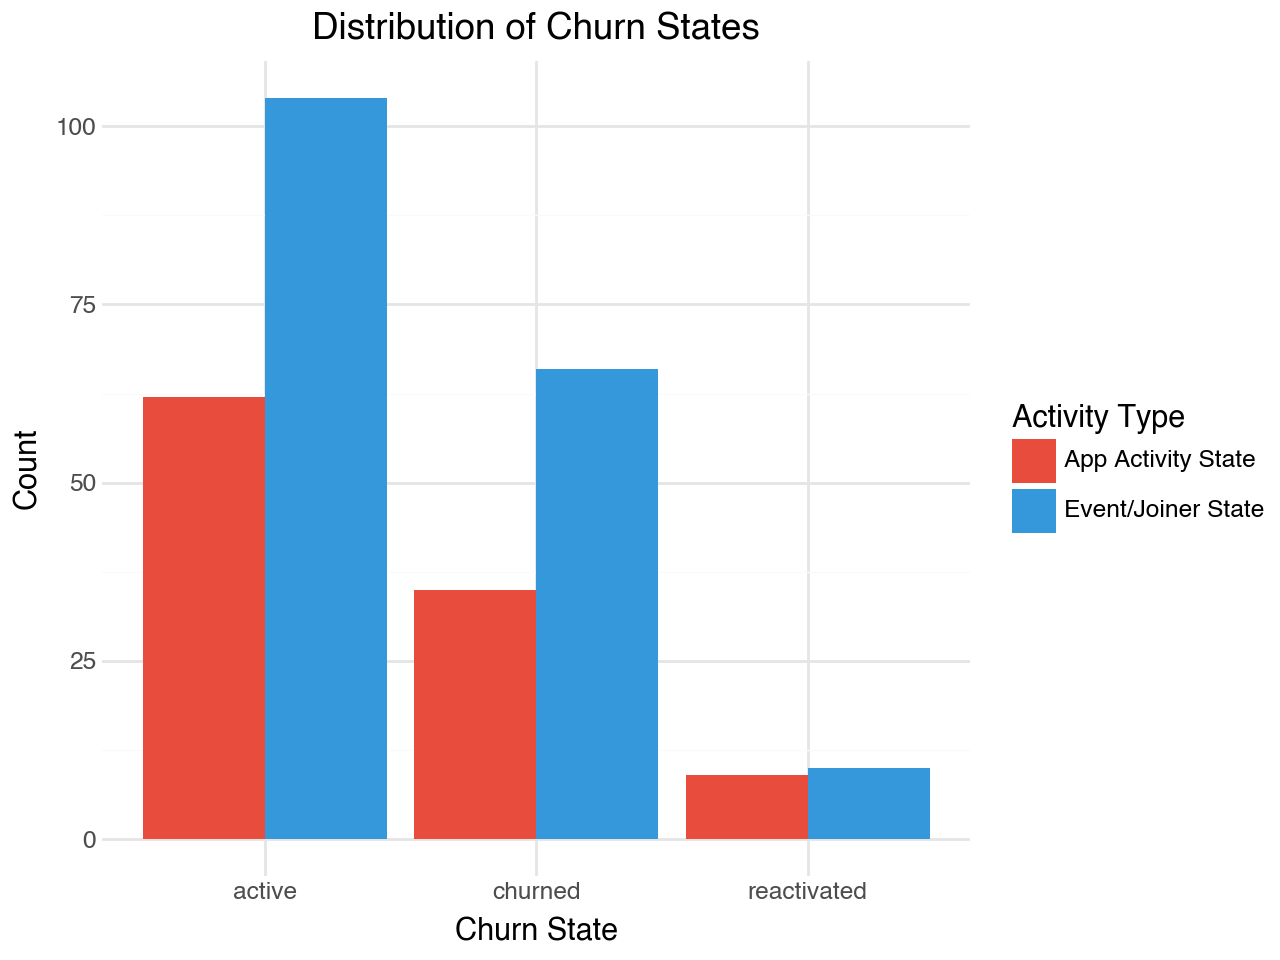

In [39]:
graph_df = churn_df.melt(id_vars=['user_id'], value_vars=['app_churn_state', 'biz_churn_state'], var_name='churn_type', value_name='churn_state')
graph_df = graph_df[graph_df['churn_state'] != 'never_active']

# Rename the churn_type values for better legend labels
graph_df['churn_type'] = graph_df['churn_type'].replace({
    'app_churn_state': 'App Activity State',
    'biz_churn_state': 'Event/Joiner State'
})

barplot = (ggplot(graph_df, aes(x='churn_state', fill='churn_type')) +
           geom_bar(position='dodge') +
           scale_fill_manual(values=['#e74c3c', '#3498db']) +  # Red and blue for distinct contrast
           labs(title='Distribution of Churn States', x='Churn State', y='Count', fill='Activity Type') +
           theme_minimal())

barplot.show()

In [ ]:
# Cohort Retention Analysis - Weekly Cohorts (Percentage-Based)
# Remove users who were never active in business activities
cohort_analysis_df = churn_df[churn_df['biz_churn_state'] != 'never_active'].copy()

# Create cohorts based on first activity week
cohort_analysis_df['first_biz_active_date'] = pd.to_datetime(cohort_analysis_df['first_biz_active_date'])
cohort_analysis_df['last_biz_active_date'] = pd.to_datetime(cohort_analysis_df['last_biz_active_date'])

# Use week number instead of month - format as "YYYY-Wxx"
cohort_analysis_df['cohort_week'] = cohort_analysis_df['first_biz_active_date'].dt.strftime('%Y-W%U')

# Calculate weeks active instead of months
cohort_analysis_df['weeks_active'] = (cohort_analysis_df['last_biz_active_date'] - 
                                       cohort_analysis_df['first_biz_active_date']).dt.days // 7

# Get cohort sizes
cohort_sizes = cohort_analysis_df.groupby('cohort_week').size()

# Create retention matrix with absolute counts
retention_counts = cohort_analysis_df.groupby(['cohort_week', 'weeks_active']).size().unstack(fill_value=0)

# Convert to percentages
retention_pct = retention_counts.div(cohort_sizes, axis=0) * 100

# Ensure all weeks 0-6 are present as columns
for week in range(7):
    if week not in retention_pct.columns:
        retention_pct[week] = 0

# Sort columns to ensure proper order
retention_pct = retention_pct.sort_index(axis=1)

# Calculate max possible weeks for each cohort
end_date_dt = pd.to_datetime('2026-02-13')
cohort_first_dates = cohort_analysis_df.groupby('cohort_week')['first_biz_active_date'].min()
max_weeks_elapsed = ((end_date_dt - cohort_first_dates).dt.days // 7).to_dict()

# Mask impossible retention periods (set to NaN)
retention_pct_masked = retention_pct.copy()
for cohort in retention_pct_masked.index:
    max_weeks = max_weeks_elapsed.get(cohort, 0)
    # Set all columns beyond the max possible weeks to NaN
    cols_to_mask = [col for col in retention_pct_masked.columns if col > max_weeks]
    retention_pct_masked.loc[cohort, cols_to_mask] = np.nan

# Create plots with masked data
fig = px.imshow(
    retention_pct_masked,
    title='Cohort Retention Heatmap - Event/Joiner Activity (% of Cohort) - Weekly',
    labels=dict(x='Weeks Since First Activity', y='Cohort Week', color='Retention %'),
    aspect='auto',
    color_continuous_scale='RdYlGn',
    text_auto='.1f'
)
fig.update_layout(yaxis_title=None)
fig.show()

In [47]:
# Cohort Retention Analysis - Weekly Cohorts (Percentage-Based)
# Remove users who were never active in app activity
cohort_analysis_df = churn_df[churn_df['app_churn_state'] != 'never_active'].copy()

# Create cohorts based on first activity week
cohort_analysis_df['first_app_active_date'] = pd.to_datetime(cohort_analysis_df['first_app_active_date'])
cohort_analysis_df['last_app_active_date'] = pd.to_datetime(cohort_analysis_df['last_app_active_date'])
# Use week number instead of month - format as "YYYY-Wxx"
cohort_analysis_df['cohort_week'] = cohort_analysis_df['first_app_active_date'].dt.strftime('%Y-W%U')

# Calculate weeks active instead of months
cohort_analysis_df['weeks_active'] = (cohort_analysis_df['last_app_active_date'] - 
                                       cohort_analysis_df['first_app_active_date']).dt.days // 7

# Get cohort sizes
cohort_sizes = cohort_analysis_df.groupby('cohort_week').size()

# Create retention matrix with absolute counts
retention_counts = cohort_analysis_df.groupby(['cohort_week', 'weeks_active']).size().unstack(fill_value=0)

# Convert to percentages
retention_pct = retention_counts.div(cohort_sizes, axis=0) * 100

# Ensure all weeks 0-6 are present as columns
for week in range(7):
    if week not in retention_pct.columns:
        retention_pct[week] = 0

# Sort columns to ensure proper order
retention_pct = retention_pct.sort_index(axis=1)

# Calculate max possible weeks for each cohort
end_date_dt = pd.to_datetime('2026-02-13')
cohort_first_dates = cohort_analysis_df.groupby('cohort_week')['first_app_active_date'].min()
max_weeks_elapsed = ((end_date_dt - cohort_first_dates).dt.days // 7).to_dict()

# Mask impossible retention periods (set to NaN)
retention_pct_masked = retention_pct.copy()
for cohort in retention_pct_masked.index:
    max_weeks = max_weeks_elapsed.get(cohort, 0)
    # Set all columns beyond the max possible weeks to NaN
    cols_to_mask = [col for col in retention_pct_masked.columns if col > max_weeks]
    retention_pct_masked.loc[cohort, cols_to_mask] = np.nan

# Create plots with masked data
fig = px.imshow(
    retention_pct_masked,
    title='Cohort Retention Heatmap - App Activity (% of Cohort) - Weekly',
    labels=dict(x='Weeks Since First Activity', y='Cohort Week', color='Retention %'),
    aspect='auto',
    color_continuous_scale='RdYlGn',
    text_auto='.1f'
)
fig.update_layout(yaxis_title=None)
fig.show()